In [16]:
from sklearn.linear_model import LinearRegression # regresión lineal
from sklearn.model_selection import train_test_split # importamos train_test_split para separar los datos
from sklearn.metrics import mean_squared_error # MSE
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.graphics.regressionplots import plot_leverage_resid2
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import extraccion.minioFunctions as mf

In [17]:
l_f = []
for k in [2022, 2023,2024, 2025]:
    print(f"Analizando el año {k}:")
    dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/Modelo_Incendios_{k}.parquet", type="df")
    l_f.append(dataf)
df_total = pd.concat(l_f, ignore_index=True)

#Borramos las columnas que no van a ser usadas en ninguna parte del análisis del modelo, 
#ni tampoco para la predicción de la variable objetivo
datos = df_total.drop(columns = ['date_last', 'count', 'lat', 'lon', 'frp_sum', 'final', 'duration_days', 'date'])
datos_conFecha = df_total.drop(columns = ['date_last', 'count', 'lat', 'lon', 'frp_sum', 'final'])

print(datos)

Analizando el año 2022:
Dataframe importado correctamente
Analizando el año 2023:
Dataframe importado correctamente
Analizando el año 2024:
Dataframe importado correctamente
Analizando el año 2025:
Dataframe importado correctamente
        frp_mean  area_ha  elevacion_centro     grados  porcentaje  temp_mean  \
0     100.760000   126.14        238.054031   6.640842   11.642637       26.1   
1     104.867143  2506.15        185.857239  10.259732   18.100486       31.8   
2     115.258889  3904.65        484.057281   6.400329   11.217379       31.8   
3      67.302500    50.31         35.344204   0.644440    1.124807       30.1   
4      57.190000    14.06       1278.932373  31.858154   62.143233       19.6   
...          ...      ...               ...        ...         ...        ...   
2679  112.500000    14.06        435.002808   1.184752    2.068078       14.5   
2680   97.354000    47.21        206.793671   2.122154    3.705553       18.4   
2681  102.190000    14.06        213.50

**Muestreo simple**

In [18]:
X = datos.drop(columns = ['frp_mean'])
y = datos['frp_mean']

#1. Dividimos en entrenamiento y 20% para validación y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, '\n')
print(X_test.shape, '\n')

print(y_train.shape, '\n')
print(y_test.shape, '\n')

(2147, 18) 

(537, 18) 

(2147,) 

(537,) 



In [19]:
#Escalamos los datos porque hay variables con escalas mucho mayores que otras
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) 

X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled, 
    columns=X_train.columns, 
    index=X_train.index
)

X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

# Ajustamos el modelo
modelo_simple2 = sm.OLS(y_train, X_train_sm).fit()
y_pred = modelo_simple2.predict(X_test_sm)

**ANÁLISIS**

**1.SUMMARY**

In [20]:
#Se hace summary (al igual que con R)
summary = modelo_simple2.summary().tables[1]
print(modelo_simple2.summary(), '\n')


                            OLS Regression Results                            
Dep. Variable:               frp_mean   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     6.752
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           7.57e-17
Time:                        16:29:13   Log-Likelihood:                -10901.
No. Observations:                2147   AIC:                         2.184e+04
Df Residuals:                    2128   BIC:                         2.195e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 86.5967      0

In [10]:
#Para ver la tabla completa 
summary = pd.DataFrame(summary)
summary.to_csv("summary.csv")
summary = pd.read_csv("summary.csv")
print(summary)

    Unnamed: 0                   0           1          2          3       4  \
0            0                 NaN        coef    std err          t   P>|t|   
1            1               const     86.5967      0.841    102.972   0.000   
2            2             area_ha      3.3697      0.858      3.926   0.000   
3            3    elevacion_centro    -15.1916      7.272     -2.089   0.037   
4            4              grados      7.3744      9.431      0.782   0.434   
5            5          porcentaje     -4.7268      9.230     -0.512   0.609   
6            6           temp_mean      2.2967     13.277      0.173   0.863   
7            7            temp_max      3.1001      7.240      0.428   0.669   
8            8            temp_min     -5.5761      7.061     -0.790   0.430   
9            9       humidity_mean     -0.8105      1.541     -0.526   0.599   
10          10       precipitation     -0.8780      0.889     -0.987   0.324   
11          11      wind_speed_max      

Se observa que tan solo 3 variables son realmente significativas en el modelo. Estas son area_ha, elevacion_centro y pressure_mean. 
Tenemos un valor de R^2 = 0.054, lo que indica que el modelo que incluye todas las variables representa tan solo un 5,4% la variable objetivo.

Valores tan altos de std error nos llevan a concluir, como en análisis previos de la anterior fase, la existencia de variables altamente correlacionadas, así como la posible existencia de multicolinealidad.

Procedemos a llevar a cabo un estudio de residuos y, tras ello, de multicolinealidad para plantear posibles soluciones.

**2.RESIDUOS VS LEVERAGE**

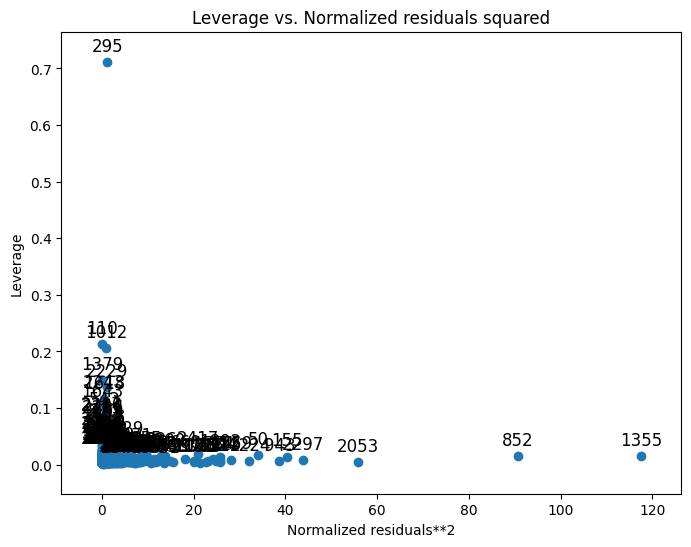

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
fig = plot_leverage_resid2(modelo_simple2, ax=ax)

Se observan valores extremadamente altos de residuos, lo que indica que una gran parte de los datos no son bien predichos por el modelo. El más alto es la observación 1355 con un valor residual de aproximadamente 11. 

El leverage no es extremadamente alto, destaca la observación 295 con un valor cercano a 0.7.

**3.QQPLOT**

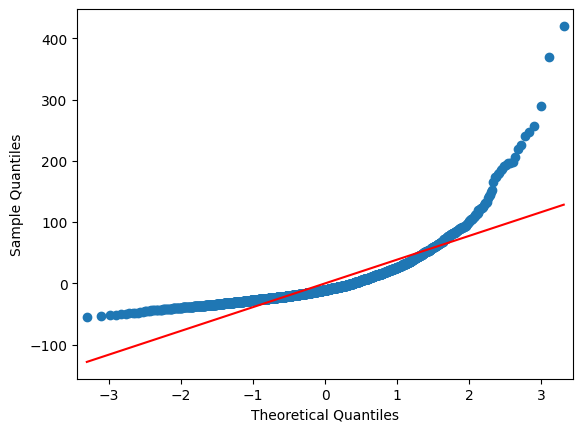

In [22]:
fig = sm.qqplot(modelo_simple2.resid, line = 's')
plt.show()

El gráfico QQplot muestra falta de normalidad en la distribución de los datos.

De la misma manera, rompe con el supuesto de linealidad.

Esta forma curva indica la necesidad de transformar la variable objetivo en escala logarítmica.

**4.DISTANCIA DE COOK**

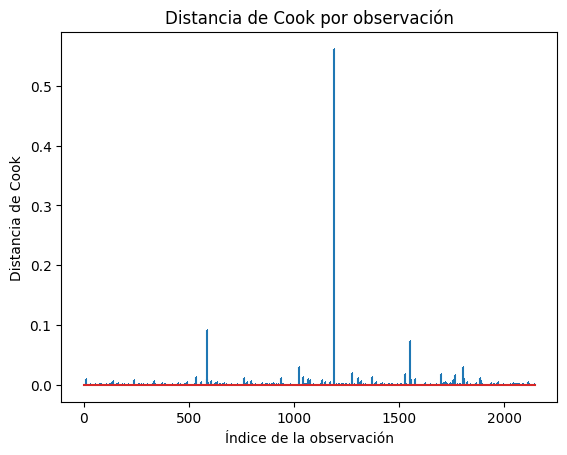

In [23]:
# 1. Obtener la influencia
influence = modelo_simple2.get_influence()

# 2. Extraer la distancia de Cook y los p-values asociados
(cooks, p_values) = influence.cooks_distance

# 3. Graficar
plt.stem(np.arange(len(cooks)), cooks, markerfmt=",")
plt.title("Distancia de Cook por observación")
plt.xlabel("Índice de la observación")
plt.ylabel("Distancia de Cook")
plt.show()

Las distancias de Cook son cercanas a 0. Destaca una elevada con un valor aproximado a 0.6. Posiblemente este dato sea el que tiene, a su vez, un alto leverage. Por lo que convendría considerarlo no solo como dato atípico, sino como una observación altamente influyente en el modelo, considerando eliminarla.

**6.MULTICOLINEALIDAD**

In [24]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_sm.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_sm.values, i) 
                   for i in range(X_train_sm.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

              Variable         VIF
5            temp_mean  249.250837
3               grados  125.765640
4           porcentaje  120.466556
2     elevacion_centro   74.773955
12       pressure_mean   74.226415
6             temp_max   74.113879
7             temp_min   70.493207
15  evapotranspiration   22.486721
14           radiation   10.240113
10      wind_speed_max    6.989763
18                NDWI    6.498976
17                NDVI    6.480531
11      wind_gusts_max    6.178375
16    sunshine_seconds    5.431157
8        humidity_mean    3.358302
13         cloud_cover    1.401571
9        precipitation    1.117893
1              area_ha    1.041828
0                const    1.000000


Todas las variables que tienen un VIF mayor que 10 indican necesariamente la existencia de multicolinealidad con otras. El claro ejemplo son las variables de temperatura, todas correlacionadas entre sí como veíamos en el análisis previo a esta fase.

Conviene llevar a cabo un proceso de selección de variables. 

**COMPROBACIÓN DE HIPÓTESIS**

In [25]:
estadistico, p_valor = stats.shapiro(modelo_simple2.resid)
print(f"P-valor Shapiro-Wilk: {p_valor}")

prueba_bp = sms.het_breuschpagan(modelo_simple2.resid, X_train_sm)
print(f"P-valor Breusch-Pagan: {prueba_bp[1]}")

P-valor Shapiro-Wilk: 4.579264753498239e-49
P-valor Breusch-Pagan: 0.12672171930406803


Un valor tan extremadamente bajo como es el obtenido en el test de Shapiro-Wilk nos lleva a concluir que los datos no cumplen con la hipótesis de normalidad. 

Por otro lado, el test de Breusch-Pagan indica que hay heterocedasticidad (aunque no es un valor extremadamente concluyente, pues es cercano a 0.05)